In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Example: Euler method for solving Ordinary Differential Equations

Lotka-Volterra equations model the predator-prey dynamics:

$x' = a x - b x y$ 

$y' = d x y - c y$

The population of prey $x$ increases proportionally to its size, and decreases proportionally to the frequency of encounters of predator and prey. The population of predators $y$ decreases proportionally to its size, and increases proportionally to the frequency of encounters with prey.

We solve the equations with explicit Euler method
$$
\vec{x}_{n+1} = \vec{x}_{n} + \Delta t f(\vec{x}_{n})
$$
where $\vec{x} = (x, y)$, $\Delta t$ is the time step, and $f(\vec{x})$ is the right hand side of the ODE.

In [8]:
T = 200.
dt = 0.1
nt = int(T/dt)
t = np.linspace(0, T, nt+1)

x = np.zeros((nt+1, 2))

# Initial conditions
x[0,:] = [100., 100.]

# Model constants
a = 0.1
b = 0.002
c = 0.2
d = 0.0025

for i in range(0, nt):
    x[i+1,0] = x[i,0] + dt*(a*x[i,0] - b*x[i,0]*x[i,1])
    x[i+1,1] = x[i,1] + dt*(d*x[i,0]*x[i,1] - c*x[i,1])

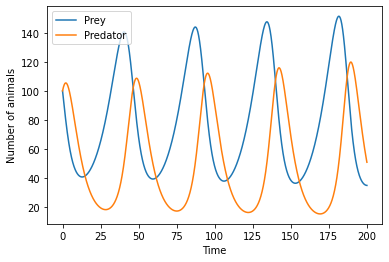

In [9]:
plt.figure()
plt.plot(t, x[:,0], label="Prey")
plt.plot(t, x[:,1], label="Predator")

plt.xlabel("Time")
plt.ylabel("Number of animals")
plt.legend()

Text(0, 0.5, 'Predator')

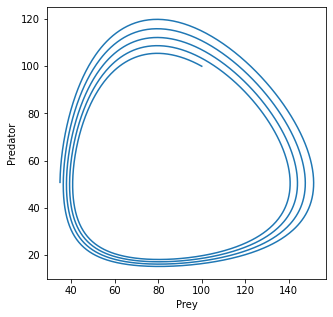

In [10]:
plt.figure(figsize=(5,5))
plt.plot(x[:,0], x[:,1])

plt.xlabel("Prey")
plt.ylabel("Predator")

### And now the same with scipy

In [11]:
import scipy.integrate
# If you don't have scipy installed, you can install it via pip:
# pip install scipy

In [12]:
def fun(t, x):
    a = 0.1
    b = 0.002
    c = 0.2
    d = 0.0025
    
    return (a*x[0] - b*x[0]*x[1], d*x[0]*x[1] - c*x[1])

T = 200.
nt = 1000
t = np.linspace(0, T, nt+1)
res = scipy.integrate.solve_ivp(fun, (0,T), (100., 100.), t_eval=t, method='RK45')
xb = res.y.T
# Save the data

Text(0, 0.5, 'Predator')

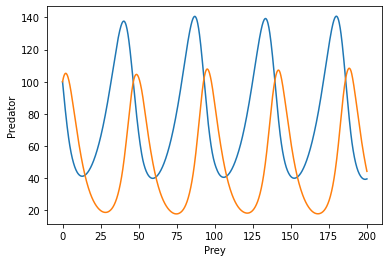

In [13]:
plt.figure()
plt.plot(t, xb[:,0])
plt.plot(t, xb[:,1])

plt.xlabel("Prey")
plt.ylabel("Predator")

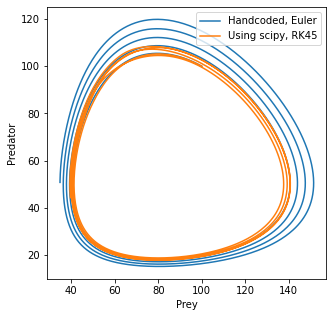

In [14]:
plt.figure(figsize=(5,5))
plt.plot(x[:,0], x[:,1], label="Handcoded, Euler")
plt.plot(xb[:,0], xb[:,1], label="Using scipy, RK45")

plt.xlabel("Prey")
plt.ylabel("Predator")
plt.legend(loc='upper right')

### Saving results locally

In [15]:
# Saving timeseries data can be done using numpy array saving functions
np.savez('results/predator_prey_timeseries.npz', time=t, prey=xb[:,0], predator=xb[:,1])
print("Timeseries data saved to 'results/predator_prey_timeseries.npz'")

Timeseries data saved to 'results/predator_prey_timeseries.npz'


### Loading saved results

Keys in the saved data: ['time', 'prey', 'predator']
[  0.    0.2   0.4 ... 199.6 199.8 200. ]
[100.          98.00085659  96.00674994 ...  39.42427577  39.49295793
  39.57630781]
[100.         100.95453702 101.81645198 ...  46.10539948  45.18047815
  44.2756377 ]
Data shapes: (1001,) (1001,) (1001,)


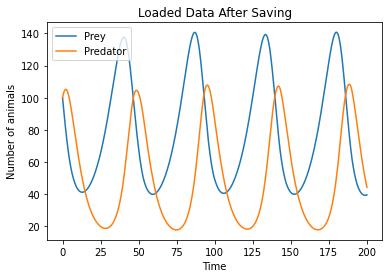

In [16]:
# The data can later be loaded using np.load
saved_data = np.load('results/predator_prey_timeseries.npz')
print('Keys in the saved data:', saved_data.files)  
print(saved_data['time'])
print(saved_data['prey'])
print(saved_data['predator'])
print('Data shapes:', saved_data['time'].shape, saved_data['prey'].shape, saved_data['predator'].shape)

# Plot loaded data to verify
plt.figure()
plt.plot(saved_data['time'], saved_data['prey'], label="Prey")
plt.plot(saved_data['time'], saved_data['predator'], label="Predator")
plt.xlabel("Time")
plt.ylabel("Number of animals")
plt.title("Loaded Data After Saving")
plt.legend()
plt.show()

Maximum prey population: 140.74333699032505 at time 180.0
Maximum predator population: 108.38272241227995 at time 188.4


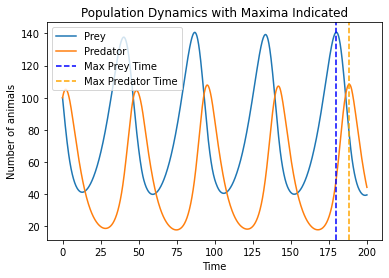

In [17]:
# Let's perform some simple analysis on the loaded data
time = saved_data['time']
prey = saved_data['prey']
predator = saved_data['predator']
max_prey = np.max(prey)
max_predator = np.max(predator)
time_of_max_prey = time[np.argmax(prey)]
time_of_max_predator = time[np.argmax(predator)]
print(f"Maximum prey population: {max_prey} at time {time_of_max_prey}")
print(f"Maximum predator population: {max_predator} at time {time_of_max_predator}")

# Plotting the time of maximum populations
plt.figure()
plt.plot(time, prey, label="Prey")
plt.plot(time, predator, label="Predator")
plt.axvline(x=time_of_max_prey, color='blue', linestyle='--', label='Max Prey Time')
plt.axvline(x=time_of_max_predator, color='orange', linestyle='--', label='Max Predator Time')
plt.xlabel("Time")
plt.ylabel("Number of animals")
plt.title("Population Dynamics with Maxima Indicated")
plt.legend()
plt.show()

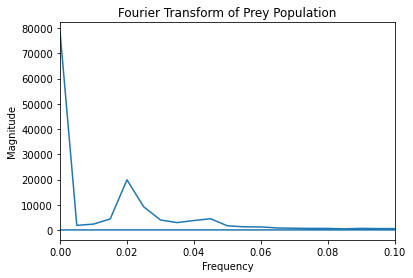

In [18]:
# Let's compute and plot the Fourier Transform of the prey population to analyze its frequency components
prey_fft = np.fft.fft(prey) # Compute Fourier Transform
frequencies = np.fft.fftfreq(len(prey), d=(time[1]-time[0])) # Compute frequency bins
plt.figure()
plt.plot(frequencies, np.abs(prey_fft)) # Plot magnitude of Fourier Transform
plt.xlim(0, 0.1)  # Limit x-axis for better visibility
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("Fourier Transform of Prey Population")
plt.show()


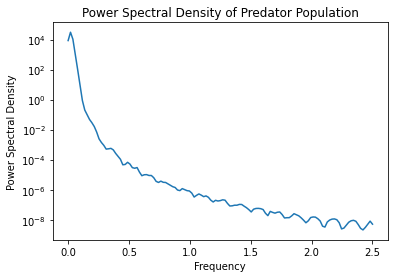

In [19]:
# Let's compute and plot the power spectral density (PSD) of the predator population
from scipy.signal import welch
frequencies, psd = welch(predator, fs=1/(time[1]-time[0]), nperseg=256) # Compute PSD using Welch's method
plt.figure()
plt.semilogy(frequencies, psd) # Plot PSD
plt.xlabel("Frequency")
plt.ylabel("Power Spectral Density")
plt.title("Power Spectral Density of Predator Population")
plt.show()


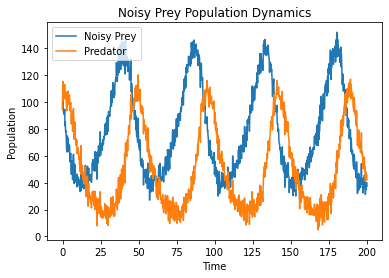

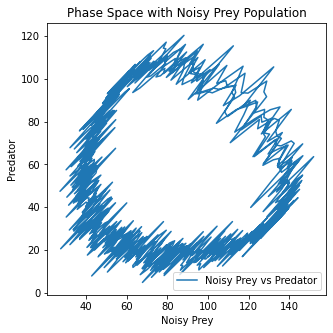

In [20]:
# Let's add some noise to the prey population and see how it affects the dynamics
noise = np.random.normal(0, 5, size=prey.shape) # Gaussian noise with mean 0 and stddev 5
noisy_prey = prey + noise # Add noise to prey population
noisy_predator = predator + noise  # Keeping predator population unchanged for comparison
plt.figure()
plt.plot(time, noisy_prey, label="Noisy Prey")
plt.plot(time, noisy_predator, label="Predator")
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Noisy Prey Population Dynamics")
plt.legend()
plt.show()

# Plot phase space of noisy prey vs predator
plt.figure(figsize=(5,5))
plt.plot(noisy_prey, noisy_predator, label="Noisy Prey vs Predator")
plt.xlabel("Noisy Prey")
plt.ylabel("Predator")
plt.title("Phase Space with Noisy Prey Population")
plt.legend()
plt.show()